# EDA for City Transit Analysis

First, I have a matrix of data points for each city. I'll plot every 5th city's points, colored by city. This is mostly just to see what's going on.

In [9]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

In [10]:
def load_comparison_data(time_diff_dir):
    csv_files = sorted(Path(time_diff_dir).glob('*.csv'))
    rows = {}
    for csv_file in csv_files:
        city = csv_file.stem[:csv_file.stem.find('_delta')-3]
        city_df = pd.read_csv(csv_file)
        key_col = city_df.columns[0]

        # flatten the city_df so each city becomes a row and each origin->destination pair becomes a column
        series = city_df.set_index(key_col).stack()
        series.index = [f"{row}->{col}" for row, col in series.index]
        rows[city] = pd.to_numeric(series)

    df = pd.DataFrame.from_dict(rows, orient='index')
    df.index.name = 'city'
    if 'home->home' in df.columns:
        df.drop(columns=['home->home'], inplace=True)
    return df

all_modality_diffs = load_comparison_data('./data/modality_deltas')


In [11]:
all_modality_diffs.head()


,home->downtown,home->nature,home->nearby city,local icon->home,local icon->downtown,local icon->nature,local icon->nearby city,grocery->home,grocery->downtown,grocery->nature,grocery->nearby city,hospital->home,hospital->downtown,hospital->nature,hospital->nearby city,stadium->home,stadium->downtown,stadium->nature,stadium->nearby city
city,,,,,,,,,,,,,,,,,,,
Akron,160,3645,9651,574,1131,2760,10408,71,263,3856,9708,275,151,3609,9990,445,-32,3887,6117
Alamosa,38,8662,32963,7612,7539,0,21773,133,91,8305,32606,25,10,8607,32908,193,151,8318,32619
Albany,72,22,3780,160,51,282,3903,130,211,119,4259,-5,59,-5,3726,331,61,469,4097
Albuquerque,408,3302,3294,1171,93,4619,2603,-1,406,3262,3239,100,245,3652,3198,440,316,4356,3649
Allentown,402,531,2251,651,196,553,1414,537,949,856,3280,203,296,368,2428,1373,635,997,855


Plot every 5th element to just look at it I guess.

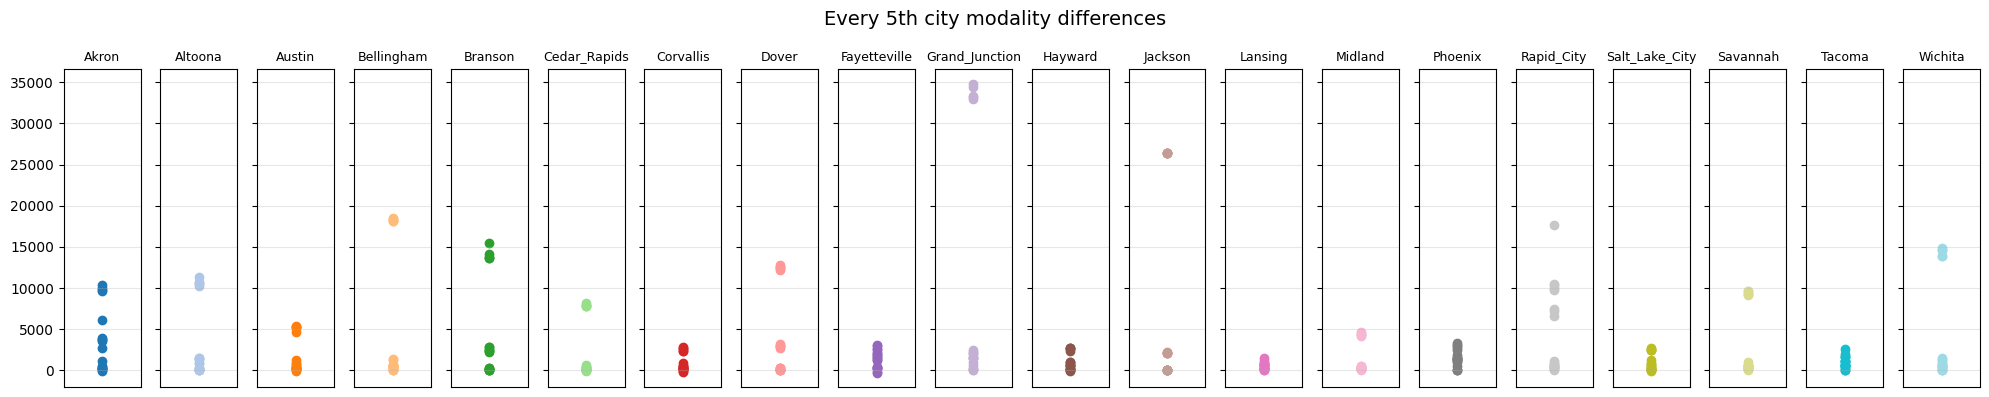

In [12]:
colors = plt.colormaps.get_cmap('tab20')

def plot_every_fifth(df, title='Every 5th city modality differences'):
    selected = df.iloc[::5]
    n = len(selected)

    fig, axes = plt.subplots(1, n, figsize=(n, 4), sharey=True)
    if n == 1:
        axes = [axes]

    for i, (city_name, row) in enumerate(selected.iterrows()):
        ax = axes[i]
        ax.scatter([0] * len(row), row.values, color=colors(i % colors.N), marker='o')
        ax.set_xlim(-0.5, 0.5)
        ax.set_xticks([])
        ax.set_xticklabels([])
        ax.set_title(city_name, fontsize=9)
        ax.grid(True, alpha=0.3)

    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    plt.show()

plot_every_fifth(all_modality_diffs)

In [14]:
# calculate variance of each dimension
variances = all_modality_diffs.var()
variances.mean()

np.float64(24075133.045217983)

I want to express this difference as some kind of percentage or ratio, because if I just average this it looks like it'll be thrown off by a nearby city being really far away or something similar.

I want to look at $\frac{t_{difference}}{t_{drive}}$ to standardize these points with drive time as a baseline, and also just the ratio $\frac{t_{bike}}{t_{drive}}$ for a metric that might be easier to interpret.

In [5]:
diff_over_drive_df = load_comparison_data('./data/mod_delta_over_drive')
diff_over_drive_df.fillna(0, inplace=True)
diff_over_drive_df.head()

,home->downtown,home->nature,home->nearby city,local icon->home,local icon->downtown,local icon->nature,local icon->nearby city,grocery->home,grocery->downtown,grocery->nature,grocery->nearby city,hospital->home,hospital->downtown,hospital->nature,hospital->nearby city,stadium->home,stadium->downtown,stadium->nature,stadium->nearby city
city,,,,,,,,,,,,,,,,,,,
Akron,0.341151,1.987459,5.160963,0.966330,2.016043,2.134571,5.209209,0.264925,0.660804,2.329909,5.357616,0.799419,0.680180,2.138033,5.953516,0.714286,-0.103226,2.569068,3.866625
Alamosa,0.808511,3.764450,4.721816,3.427285,3.411312,0.000000,3.020671,0.715054,0.631944,3.610870,4.671347,0.210084,0.138889,3.714717,4.703158,1.184049,1.247934,3.653052,4.688659
Albany,0.153846,0.271605,2.184971,0.329218,0.554348,0.694581,2.385697,0.414013,0.430612,0.508547,2.749516,-0.048077,0.117296,-0.045045,2.145078,0.767981,0.677778,1.340000,2.593038
Albuquerque,0.804734,2.559690,2.145928,1.649296,0.194969,3.743112,1.757596,-0.038462,0.760300,2.507302,2.095084,0.427350,0.553047,3.134764,2.268085,1.173333,0.721461,3.882353,2.669349
Allentown,0.655791,0.848243,2.000889,0.687434,0.417021,1.057361,1.265891,0.870340,1.125741,1.573529,2.451420,0.722420,0.930818,1.076023,2.288407,1.284378,0.843293,1.485842,0.873340


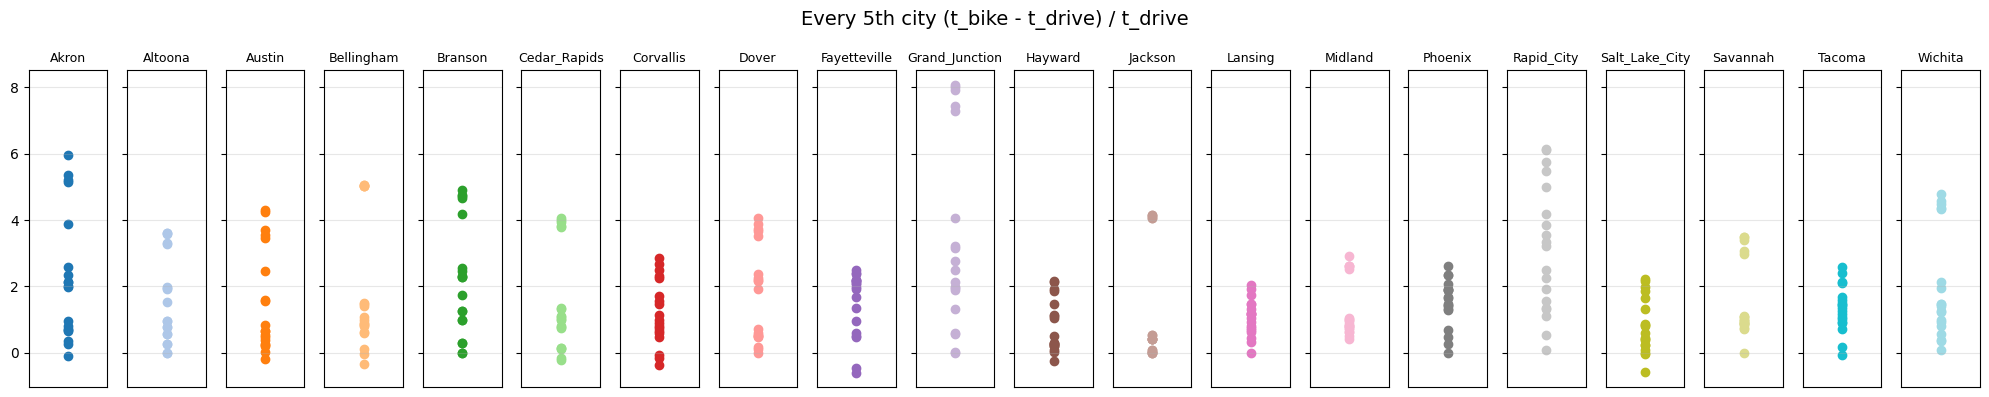

In [6]:
plot_every_fifth(diff_over_drive_df, title='Every 5th city (t_bike - t_drive) / t_drive')

Now the same comparison, but for the more easily interpretable ratio $\frac{t_{bike}}{t_{drive}}$

In [7]:
bike_over_drive_df = load_comparison_data('./data/bike_over_drive')
bike_over_drive_df.fillna(0, inplace=True)
bike_over_drive_df.head()

,home->downtown,home->nature,home->nearby city,local icon->home,local icon->downtown,local icon->nature,local icon->nearby city,grocery->home,grocery->downtown,grocery->nature,grocery->nearby city,hospital->home,hospital->downtown,hospital->nature,hospital->nearby city,stadium->home,stadium->downtown,stadium->nature,stadium->nearby city
city,,,,,,,,,,,,,,,,,,,
Akron,1.341151,2.987459,6.160963,1.966330,3.016043,3.134571,6.209209,1.264925,1.660804,3.329909,6.357616,1.799419,1.680180,3.138033,6.953516,1.714286,0.896774,3.569068,4.866625
Alamosa,1.808511,4.764450,5.721816,4.427285,4.411312,0.000000,4.020671,1.715054,1.631944,4.610870,5.671347,1.210084,1.138889,4.714717,5.703158,2.184049,2.247934,4.653052,5.688659
Albany,1.153846,1.271605,3.184971,1.329218,1.554348,1.694581,3.385697,1.414013,1.430612,1.508547,3.749516,0.951923,1.117296,0.954955,3.145078,1.767981,1.677778,2.340000,3.593038
Albuquerque,1.804734,3.559690,3.145928,2.649296,1.194969,4.743112,2.757596,0.961538,1.760300,3.507302,3.095084,1.427350,1.553047,4.134764,3.268085,2.173333,1.721461,4.882353,3.669349
Allentown,1.655791,1.848243,3.000889,1.687434,1.417021,2.057361,2.265891,1.870340,2.125741,2.573529,3.451420,1.722420,1.930818,2.076023,3.288407,2.284378,1.843293,2.485842,1.873340


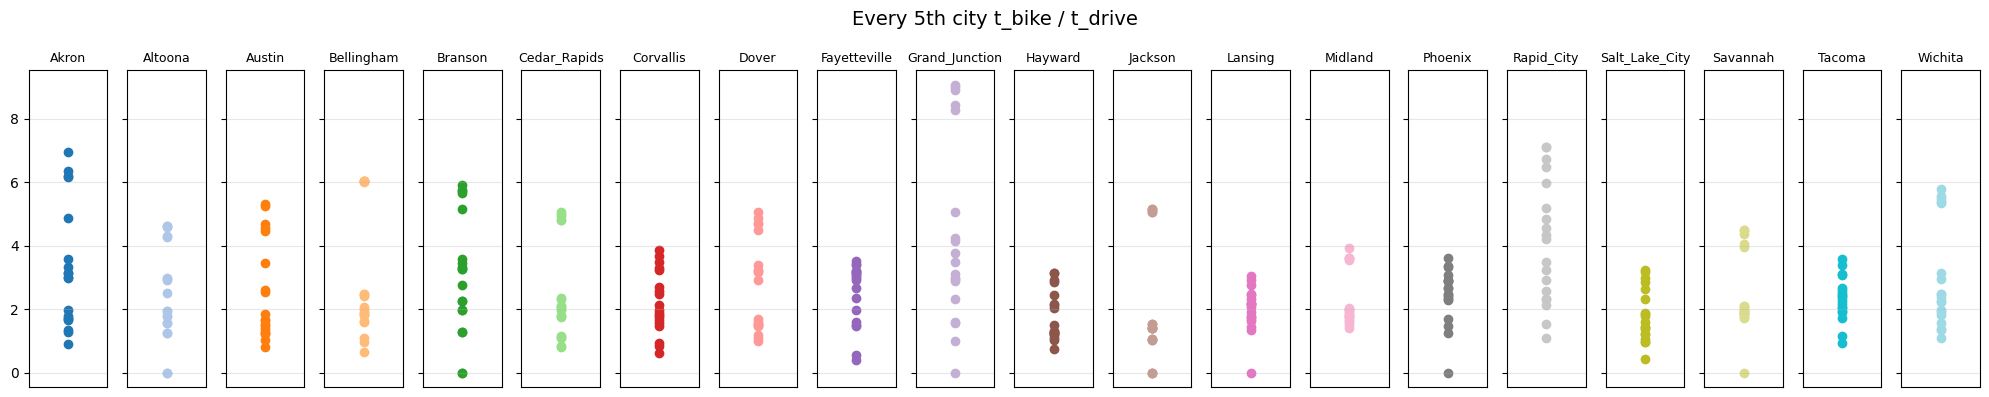

In [8]:
plot_every_fifth(bike_over_drive_df, title='Every 5th city t_bike / t_drive')

It looks like the $\frac{t_{difference}}{t_{drive}}$ and $\frac{t_{bike}}{t_{drive}}$ are basically the same, and after a few seconds of math on a paper, they represent essentially the same data. And upon even more reflection, this actually doesn't really matter too much for most of these data analysis techniques. I may get an average value for each city just for fun but it doesn't really matter. Also I might try to create a dataset where I remove the labels from the city points, order them within the city based on just their value, and compare the cities that way to get some kind of a blind transportation look at the cities.